In [1]:
from functools import partial
from typing import Callable, Tuple

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.utils import tree_replace

In [2]:
SEED = 0
INPUT_DIM = 20
TARGET_NOISE = 0.1

In [76]:
def make_task():
    rng = jax.random.PRNGKey(SEED)
    return FeatureSiftingTask(n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=rng)


class LearnerState(eqx.Module):
    weights: jax.Array


@partial(jax.jit, static_argnames=('update_fn', 'steps'))
def run_train_loop(
    update_fn: Callable[[LearnerState, np.ndarray, np.ndarray], Tuple[LearnerState, np.ndarray]],
    learner_state: LearnerState,
    task: FeatureSiftingTask,
    steps: int,
):
    def _get_noise_floor(task: FeatureSiftingTask):
        # Vectorized over each target feature index, no explicit loop.
        # For each target: get all positions with that idx and take the minimum noise; if none, use 1.0.
        target_indices = jnp.arange(task.n_target_features)
        def min_noise_for_idx(idx):
            mask = (task.learner_feature_idxs == idx)
            min_noise = jnp.where(
                mask.any(),
                jnp.min(jnp.where(mask, task.noise_coefficients, 1.0)),
                1.0
            )
            return min_noise
        min_noise_vals = jax.vmap(min_noise_for_idx)(target_indices)
        return jnp.sum(min_noise_vals)
    
    def _train_step(carry, _):
        learner_state, task, x, y = carry
        
        ### Forward pass ###
        pred = x @ learner_state.weights
        error = y - pred
        loss = error ** 2
        
        ### Update ###
        learner_state, prune_mask, metrics = update_fn(learner_state, x, y)
        
        ### New sample ###
        task, (x, y) = task.step(prune_mask)
        
        return (learner_state, task, x, y), {
            'loss': loss,
            'noise_floor': _get_noise_floor(task),
            **metrics,
        }
    
    task, (x, y) = task.step(jnp.zeros(INPUT_DIM))
    learner_state, metrics = jax.lax.scan(
        _train_step,
        (learner_state, task, x, y),
        length = steps,
    )
    
    return metrics


def run_sweep(run_one, sweep_values, seeds):
    """Runs `run_one(value, seed)` for every pair: inner vmap over seeds, outer over swept values."""
    return jax.vmap(
        jax.vmap(run_one, in_axes=(None, 0)),  # seeds
        in_axes=(0, None),                     # swept values
    )(sweep_values, seeds)


def plot_learning_curves(metrics, sweep_values, sweep_name, log_freq=500, metric_name='loss'):
    """Plots one learning curve per swept value, averaged over seeds."""
    def fmt(v):
        # Show powers of 2 or 10 as exponents (e.g. 0.01 -> 10^-2), else the plain value.
        # Compare in value-space so float32 imprecision (0.001 -> 0.00100000004) still matches.
        v = float(v)
        if v > 0:
            for base in (2, 10):
                exp = round(np.log(v) / np.log(base))
                if np.isclose(v, float(base) ** exp, rtol=1e-3):
                    return f'${base}^{{{exp}}}$'
        return f'{v:g}'

    metric_vals = np.asarray(metrics[metric_name])  # (n_values, n_seeds, steps, 1)
    n_values, n_seeds, steps = metric_vals.shape[:3]
    curves = metric_vals.reshape(n_values, n_seeds, -1, log_freq).mean(axis=(1, 3))
    steps_axis = np.arange(steps)[::log_freq]

    plt.xlabel('Step')
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.title('Learning Curve')
    for value, curve in zip(sweep_values, curves):
        plt.plot(steps_axis, curve, label=f'{fmt(value)}')
    plt.legend(title=sweep_name)
    plt.grid(True)
    # plt.show()

# Vmapped Sweeps

Same flow as the sections above (define parameters → define the algorithm → run the training loop → plot). Each section sweeps **one** variable; two shared helpers in the setup cell keep the vmapping and plotting boilerplate out of each algorithm:

- **`run_sweep(run_one, sweep_values, seeds)`** wraps `run_one` in two levels of `vmap` — an inner one over seeds (averaged together) and an outer one over the swept values (one curve each) — returning metrics of shape `(n_values, n_seeds, train_steps, 1)`.
- **`plot_learning_curves(metrics, sweep_values, sweep_name)`** averages over the seed axis and plots one labeled learning curve per swept value. Values that are powers of 2 or 10 are shown as `2^k` / `10^k` in the legend.

So each algorithm below only defines its state, its update, and a small `run_one(value, seed)` that builds the task + algorithm and trains it — then sets `sweep_name` / `sweep_values` and calls the two helpers. We sweep 3 step sizes over 5 seeds for both V1 (LMS) and V2 (utility-based pruning).

## V1 (vmapped): LMS

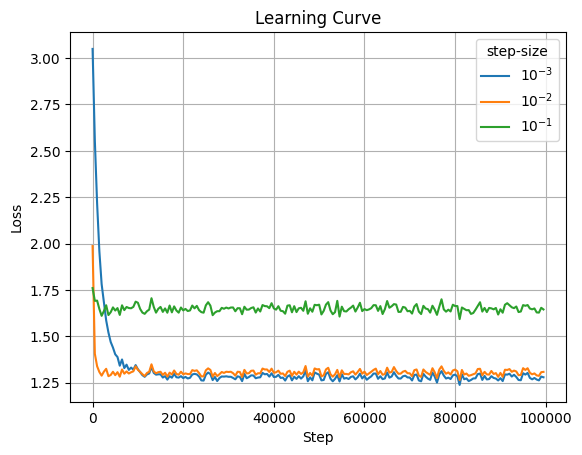

In [77]:
### Algorithm: LMS ###
class LMSState(LearnerState):
    step_size: float

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = jnp.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask, {}

### Parameters ###
train_steps = 100_000

### Sweep: one variable over 30 seeds ###
seeds = jnp.arange(30)
sweep_name = 'step-size'
sweep_values = jnp.array([0.001, 0.01, 0.1])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(step_size, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = LMSState(jnp.zeros(INPUT_DIM), step_size)
    return run_train_loop(lms_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)

## V2 (vmapped): Simple Utility-Based Pruning

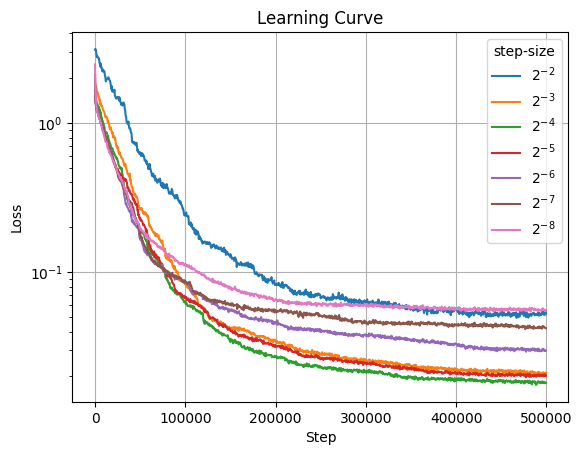

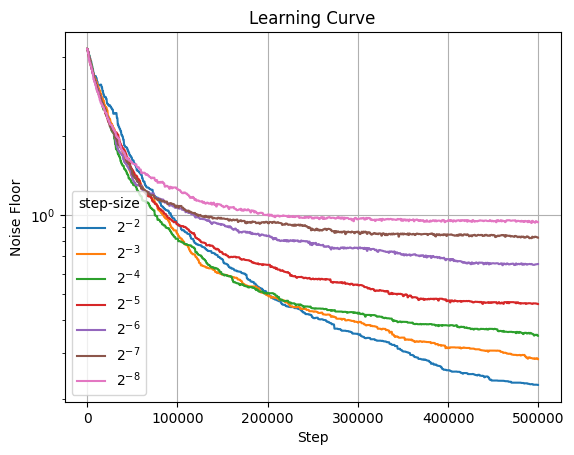

In [78]:
### Algorithm: utility-based pruning ###
class V2State(LearnerState):
    step_size: float
    prune_freq: int = eqx.field(static=True)
    step_idx: jax.Array

def v2_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    weights = learner_state.weights - learner_state.step_size * grad

    ### Pruning: every prune_freq steps, drop the lowest-utility feature ###
    step_idx = learner_state.step_idx + 1
    should_prune = (step_idx % learner_state.prune_freq) == 0
    utilities = jnp.abs(weights)
    prune_mask = should_prune * jax.nn.one_hot(jnp.argmin(utilities), INPUT_DIM)
    weights = jnp.where(prune_mask, 0.0, weights)

    new_state = tree_replace(learner_state, weights=weights, step_idx=step_idx)
    return new_state, prune_mask, {}

### Parameters ###
train_steps = 500_000

### Hyperparameters (fixed) ###
prune_freq = 1000

### Sweep: one variable over 30 seeds ###
seeds = jnp.arange(30)
sweep_name = 'step-size'
sweep_values = jnp.array([2**-2, 2**-3, 2**-4, 2**-5, 2**-6, 2**-7, 2**-8])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(step_size, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = V2State(jnp.zeros(INPUT_DIM), step_size, prune_freq, jnp.array(0))
    return run_train_loop(v2_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)
# plt.ylim(0.0, 1.5)
plt.yscale('log')
plt.show()
plot_learning_curves(metrics, sweep_values, sweep_name, metric_name='noise_floor')
# plt.ylim(0.5, 3.0)
plt.yscale('log')

### Sweep over prune period

/tmp/ipykernel_38789/3226800303.py:17: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  algo_state = V2State(jnp.zeros(INPUT_DIM), step_size, prune_freq, jnp.array(0))


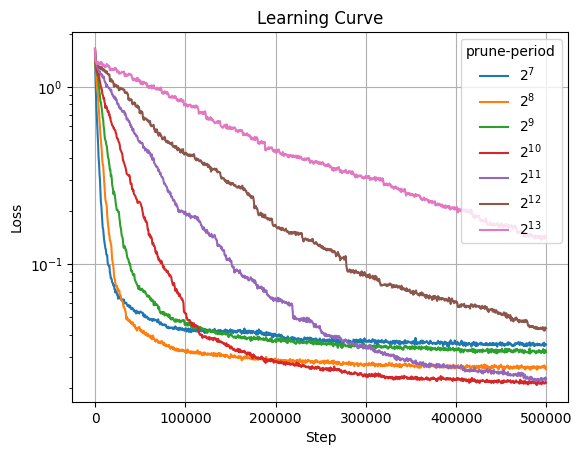

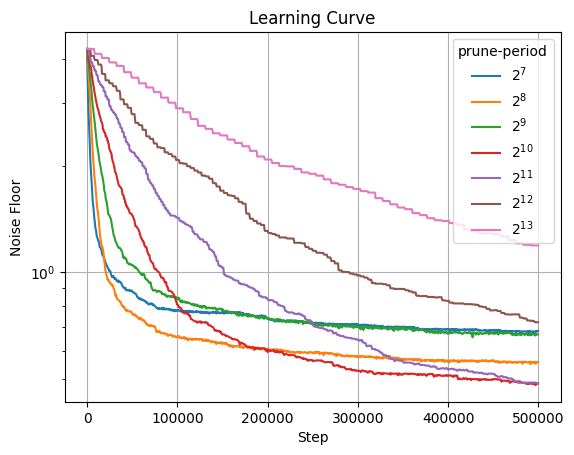

In [79]:
### Parameters ###
train_steps = 500_000

### Hyperparameters (fixed) ###
step_size = 2**-5

### Sweep: one variable over 30 seeds ###
seeds = jnp.arange(30)
sweep_name = 'prune-period'
sweep_values = jnp.array([2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(prune_freq, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = V2State(jnp.zeros(INPUT_DIM), step_size, prune_freq, jnp.array(0))
    return run_train_loop(v2_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)
plt.yscale('log')
plt.show()
plot_learning_curves(metrics, sweep_values, sweep_name, metric_name='noise_floor')
plt.yscale('log')

# V3: Adaptive Pruning Rate

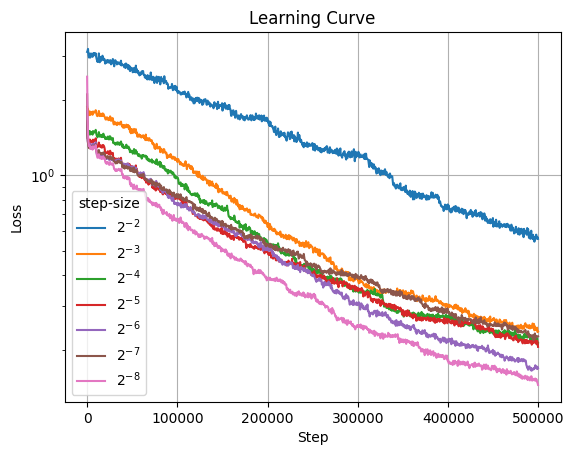

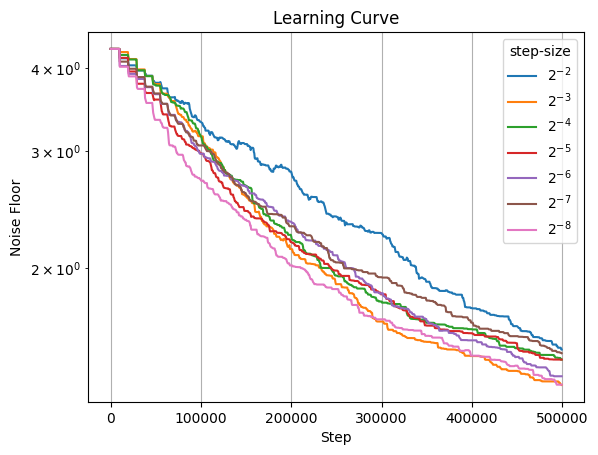

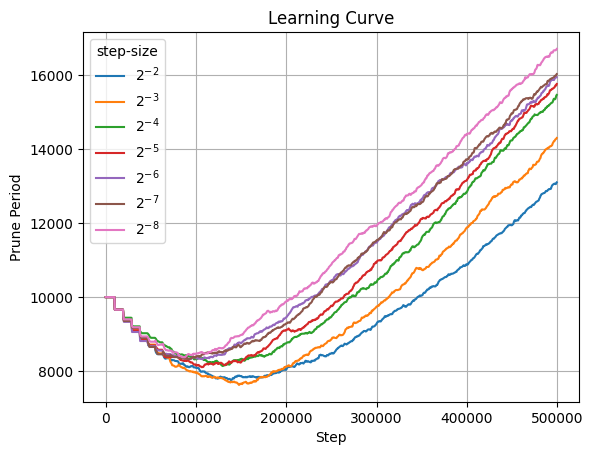

In [106]:
### Algorithm: utility-based pruning ###
class V3State(LearnerState):
    prune_freq: float
    step_size: float
    rate_increment: float
    steps_since_prune: jax.Array
    age: jax.Array = jnp.zeros(INPUT_DIM)


def v3_update(learner_state, x, y):
    maturity_threshold = learner_state.prune_freq * learner_state.weights.size * 0.5

    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    weights = learner_state.weights - learner_state.step_size * grad

    ### Pruning: every prune_freq steps, drop the lowest-utility feature ###
    # Integer countdown vs the ROUNDED period — never modulo a fractional prune_freq.
    period = jnp.maximum(jnp.round(learner_state.prune_freq), 1.0)
    steps_since_prune = learner_state.steps_since_prune + 1
    should_prune = steps_since_prune >= period
    utilities = jnp.abs(weights)
    prune_mask = should_prune * jax.nn.one_hot(jnp.argmin(utilities), INPUT_DIM)

    ############

    feature_age = learner_state.age

    # Decrease: features that CROSS maturity this step (one signal per crossing).
    decrease_mask = (feature_age < maturity_threshold) & (feature_age + 1 >= maturity_threshold)
    n_decrease_signals = jnp.sum(decrease_mask)

    # Increase: pruned features whose age < maturity_threshold
    increase_mask = (prune_mask.astype(bool)) & (feature_age < maturity_threshold)
    n_increase_signals = jnp.sum(increase_mask)

    net_signals = n_increase_signals - n_decrease_signals
    prune_freq = learner_state.prune_freq * (2 ** (net_signals * learner_state.rate_increment))

    ############

    prune_age = jnp.where(prune_mask.sum() == 0, jnp.nan, learner_state.age[jnp.argmax(prune_mask)])

    weights = jnp.where(prune_mask, 0.0, weights)
    age = jnp.where(prune_mask, 0.0, learner_state.age + 1)
    steps_since_prune = jnp.where(should_prune, 0, steps_since_prune)

    new_state = tree_replace(
        learner_state, weights=weights, steps_since_prune=steps_since_prune, age=age, prune_freq=prune_freq,
    )
    return new_state, prune_mask, {'prune_period': prune_freq, 'prune_age': prune_age}

### Parameters ###
train_steps = 100_000

### Hyperparameters (fixed) ###
prune_freq = 1000
rate_increment = 0.01

### Sweep: one variable over 30 seeds ###
seeds = jnp.arange(30)
sweep_name = 'step-size'
sweep_values = jnp.array([2**-2, 2**-3, 2**-4, 2**-5, 2**-6, 2**-7, 2**-8])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(step_size, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = V3State(jnp.zeros(INPUT_DIM), prune_freq, step_size, rate_increment, jnp.array(0), jnp.zeros(INPUT_DIM))
    return run_train_loop(v3_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)
plt.yscale('log')
plt.show()
plot_learning_curves(metrics, sweep_values, sweep_name, metric_name='noise_floor')
plt.yscale('log')
plt.show()
plot_learning_curves(metrics, sweep_values, sweep_name, metric_name='prune_period')
# plt.ylim(0.5, 3.0)
# plt.yscale('log')


In [87]:
metrics['prune_age'][~jnp.isnan(metrics['prune_age'])]

Array([99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99.,
       99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99., 99

In [75]:
for i in range(21):
    print(2**(10 + (i * 0.1)))
# np.exp(6.9)

1024.0
1097.496025637164
1176.2671155169633
1260.691879265195
1351.1761006314441
1448.1546878700494
1552.0937641066473
1663.4929077375696
1782.8875536304631
1910.851566667382
2048.0
2194.992051274328
2352.5342310339265
2521.38375853039
2702.3522012628882
2896.309375740099
3104.1875282132946
3326.985815475139
3565.7751072609262
3821.703133334764
4096.0
